# Milestone 2: Exploratory Data Analysis

## 1. Dataset Selection

### Music Genre and Emotion Dataset

Dataset Link: https://www.kaggle.com/datasets/colabsss/multimodal-music-genre-and-emotion-dataset

Dataset License: CC0: Public Domain

This dataset includes five thousand different songs, each with several features ascribed to them. These features describe the song's genre, tempo, energy, danceability, loudness, acousticness, instrumentalness, and valence, with these being used to predict a target variable of emotion. Each entry also has an ID associated with it, which is redundant for prediction purposes as each song has a unique ID. With the exception of genre, all of these features are continuous double values, and there are several different discrete values for the target. This could make classification more challenging, especially if one or more target clusters lack clear separation from its neighbors.

This dataset required very little cleaning, as there were no columns with missing or corrupted data that needed to be corrected. In the loudness column, some values read -0.0 instead of 0.0, which were normalized. Before proceeding to Phase 3, the dataset will be pruned of the Track_ID column since it is completely useless for prediction purposes and pandas already has native row IDs for dataframes. A second copy of the dataset will also be created, lacking the Emotion_Label column, as this target variable will need to be excluded from training and testing, while keeping a copy with said value intact for measuring accuracy, precision, and entropy.

In [1]:
# Libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the raw dataset
df = pd.read_csv("../data/raw_dataset.csv")

# Numeric audio features used throughout the notebook
FEATURES = ["Tempo", "Energy", "Danceability", "Loudness",
            "Acousticness", "Instrumentalness", "Valence"]

print(df.shape)
df.head()

(5000, 10)


,Track_ID,Genre,Tempo,Energy,Danceability,Loudness,Acousticness,Instrumentalness,Valence,Emotion_Label
0,T00001,classical,112.44,0.394,0.374,-30.02,0.730,0.092,0.638,happy
1,T00002,blues,193.10,0.473,0.333,-15.20,0.185,0.061,0.459,sad
2,T00003,hiphop,162.48,0.855,0.176,-26.24,0.347,0.604,0.964,calm
3,T00004,disco,143.81,0.340,0.607,-55.00,0.663,0.966,0.219,romantic
4,T00005,disco,81.84,0.870,0.477,-48.87,0.482,0.503,0.588,angry


In [2]:
# Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track_ID          5000 non-null   str    
 1   Genre             5000 non-null   str    
 2   Tempo             5000 non-null   float64
 3   Energy            5000 non-null   float64
 4   Danceability      5000 non-null   float64
 5   Loudness          5000 non-null   float64
 6   Acousticness      5000 non-null   float64
 7   Instrumentalness  5000 non-null   float64
 8   Valence           5000 non-null   float64
 9   Emotion_Label     5000 non-null   str    
dtypes: float64(7), str(3)
memory usage: 390.8 KB


In [3]:
# Summary statistics for the numeric features
df[FEATURES].describe().round(3)

,Tempo,Energy,Danceability,Loudness,Acousticness,Instrumentalness,Valence
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,129.556,0.491,0.501,-29.539,0.509,0.491,0.501
std,40.549,0.286,0.291,17.268,0.289,0.285,0.288
min,60.000,0.000,0.000,-59.980,0.000,0.000,0.000
25%,94.142,0.247,0.247,-44.235,0.259,0.247,0.248
50%,130.000,0.486,0.496,-29.250,0.513,0.491,0.502
75%,164.735,0.733,0.761,-14.930,0.758,0.732,0.748
max,199.960,1.000,1.000,-0.000,1.000,1.000,1.000


## 2. Data Visualization

### 2.1 Genre Distribution

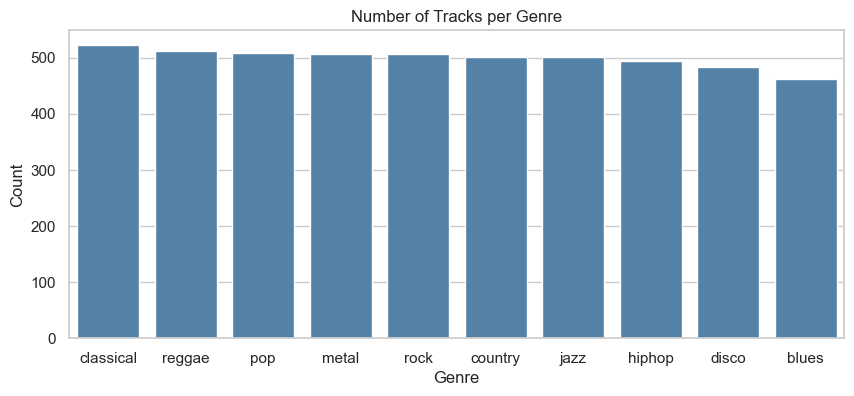

In [4]:
# Count how many tracks belong to each genre
genre_counts = df["Genre"].value_counts()

plt.figure(figsize=(10, 4))
sns.barplot(x=genre_counts.index, y=genre_counts.values, color="steelblue")
plt.title("Number of Tracks per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

- Shows the number of tracks in each of the 10 genres.
- Classes are roughly balanced (about 460 to 520 tracks each), so no resampling is needed.

### 1.2 Emotion Distribution

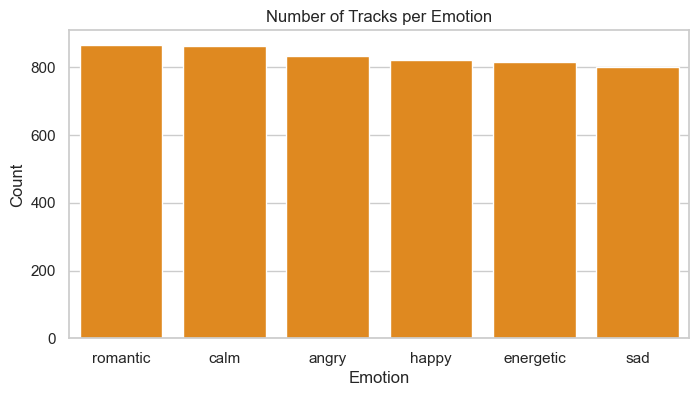

In [5]:
# Count how many tracks have each emotion label
emotion_counts = df["Emotion_Label"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, color="darkorange")
plt.title("Number of Tracks per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

- Shows the number of tracks for each of the 6 emotion labels.
- Emotions are also balanced (about 800 to 870 tracks each).

### 2.3 Feature Distributions

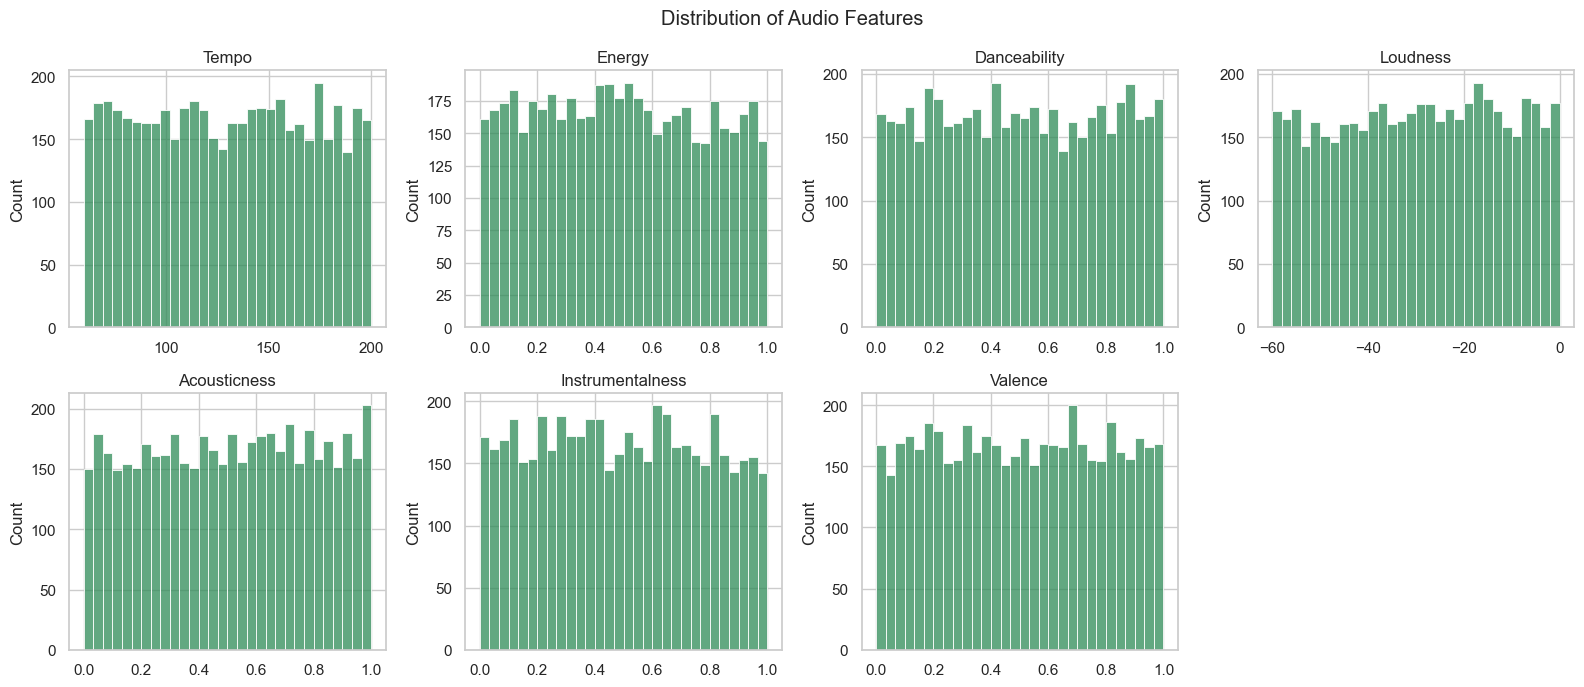

In [6]:
# One histogram per numeric feature
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(df[col], bins=30, ax=ax, color="seagreen")
    ax.set_title(col)
    ax.set_xlabel("")

# Hide the unused 8th subplot
axes.flat[-1].set_visible(False)
plt.suptitle("Distribution of Audio Features")
plt.tight_layout()
plt.show()

- Shows the spread of values for each audio feature.
- Every feature is roughly flat (uniform) across its range rather than bell-shaped.
- Tempo covers 60–200 BPM and Loudness covers -60 to 0 dB, while the other features are between 0 and 1, so scaling will be needed later.

### 2.4 Features by Genre

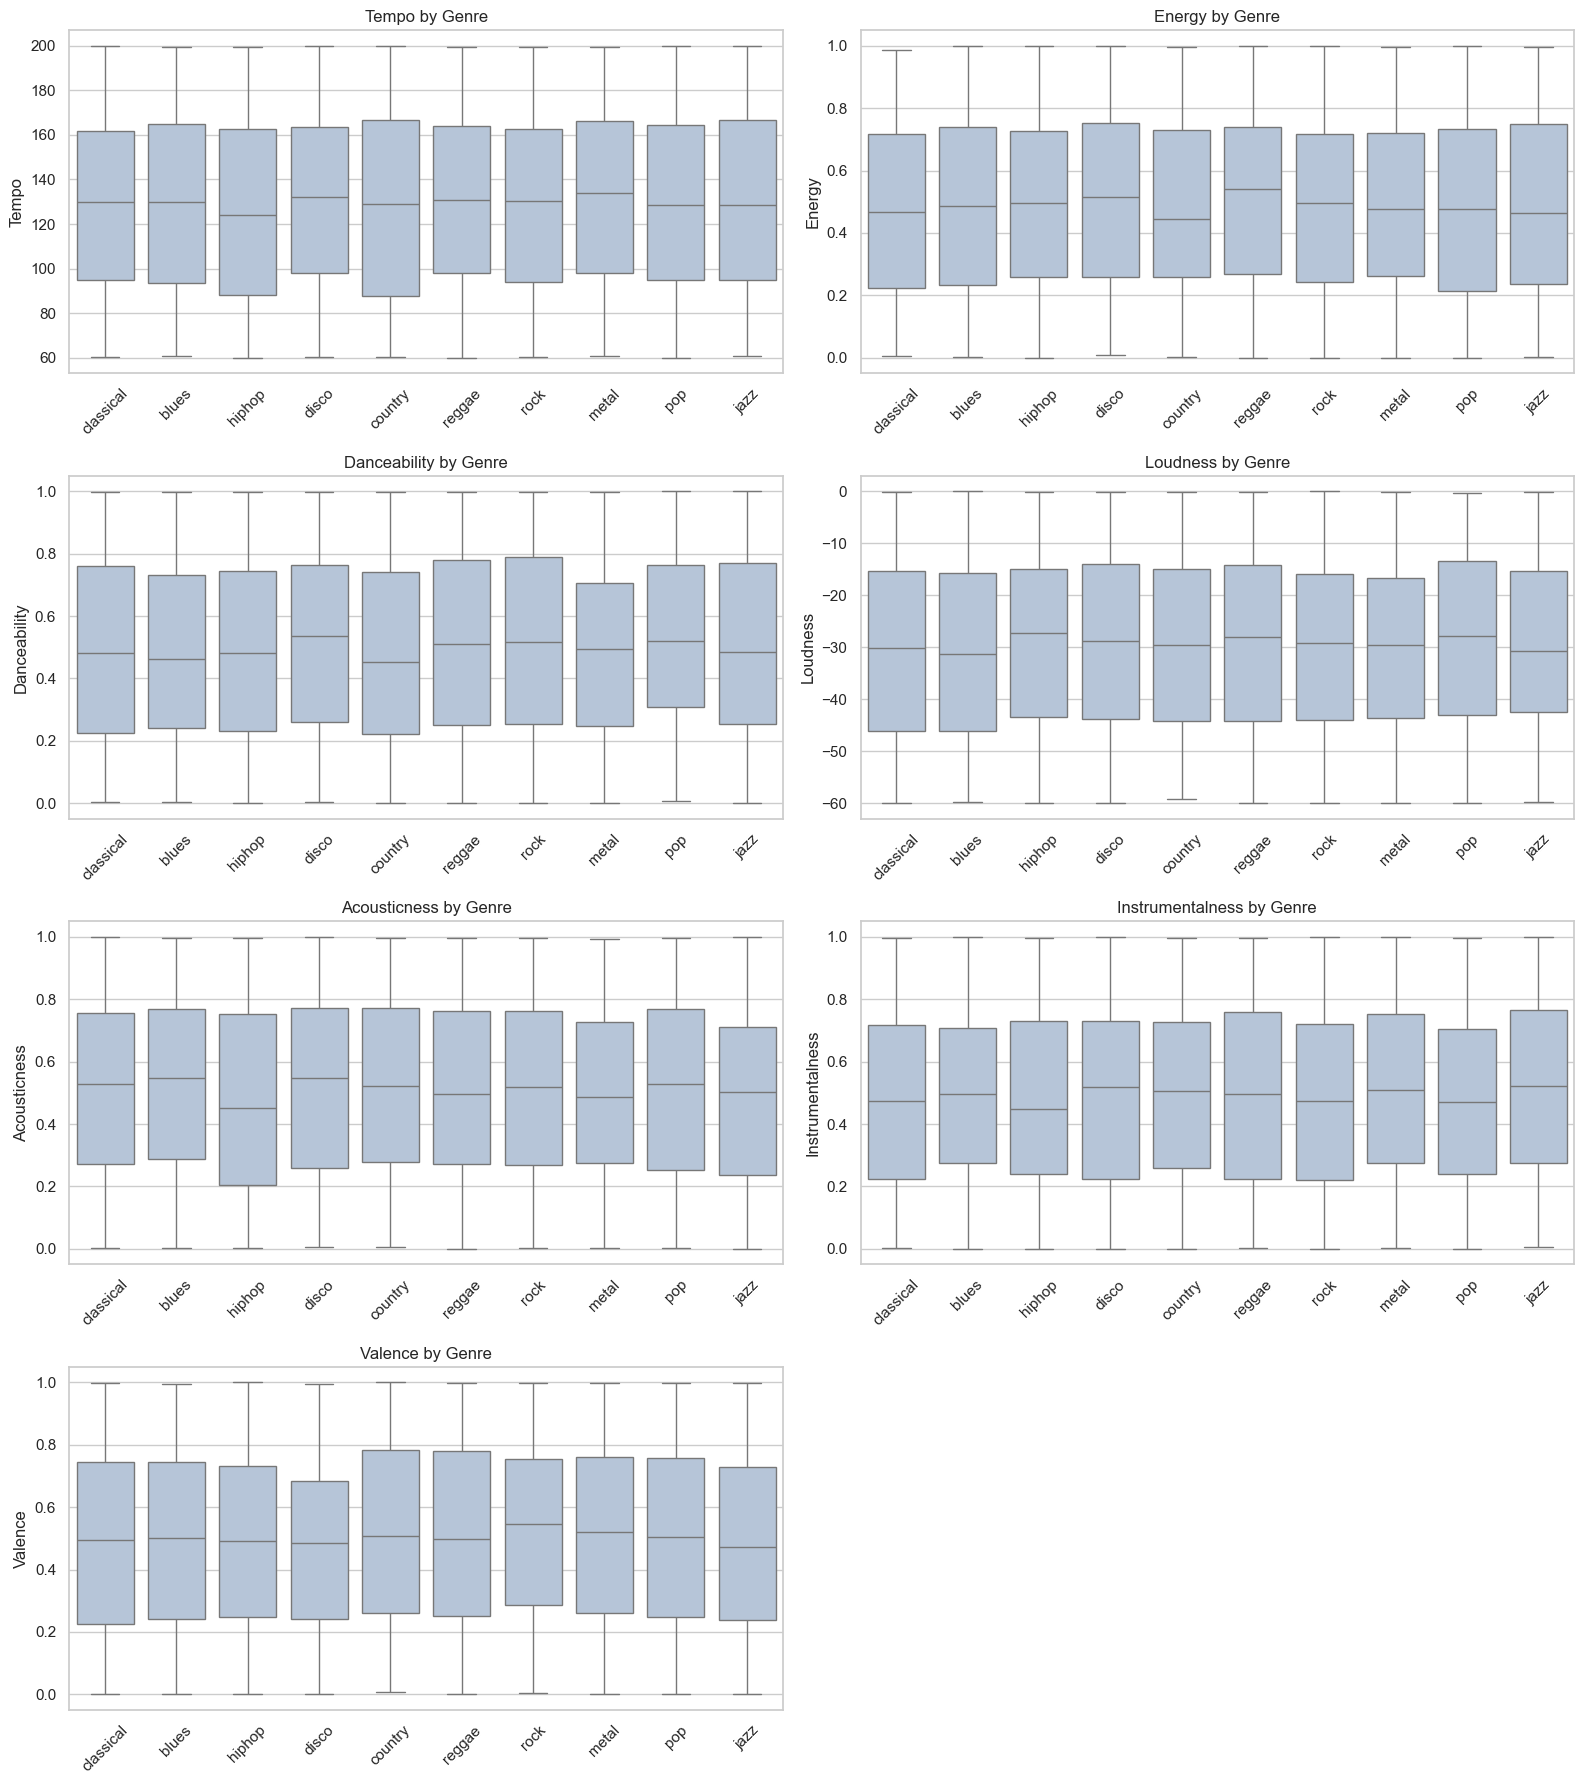

In [7]:
# Box plot of each feature split by genre
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x="Genre", y=col, ax=ax, color="lightsteelblue")
    ax.set_title(f"{col} by Genre")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

# Hide the unused 8th subplot
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

- Compares the range of each feature across the 10 genres.
- The boxes are almost identical for every genre (e.g. metal has about the same energy as classical).
- This suggests the features on their own may not separate genres well.

### 2.5 Features by Emotion

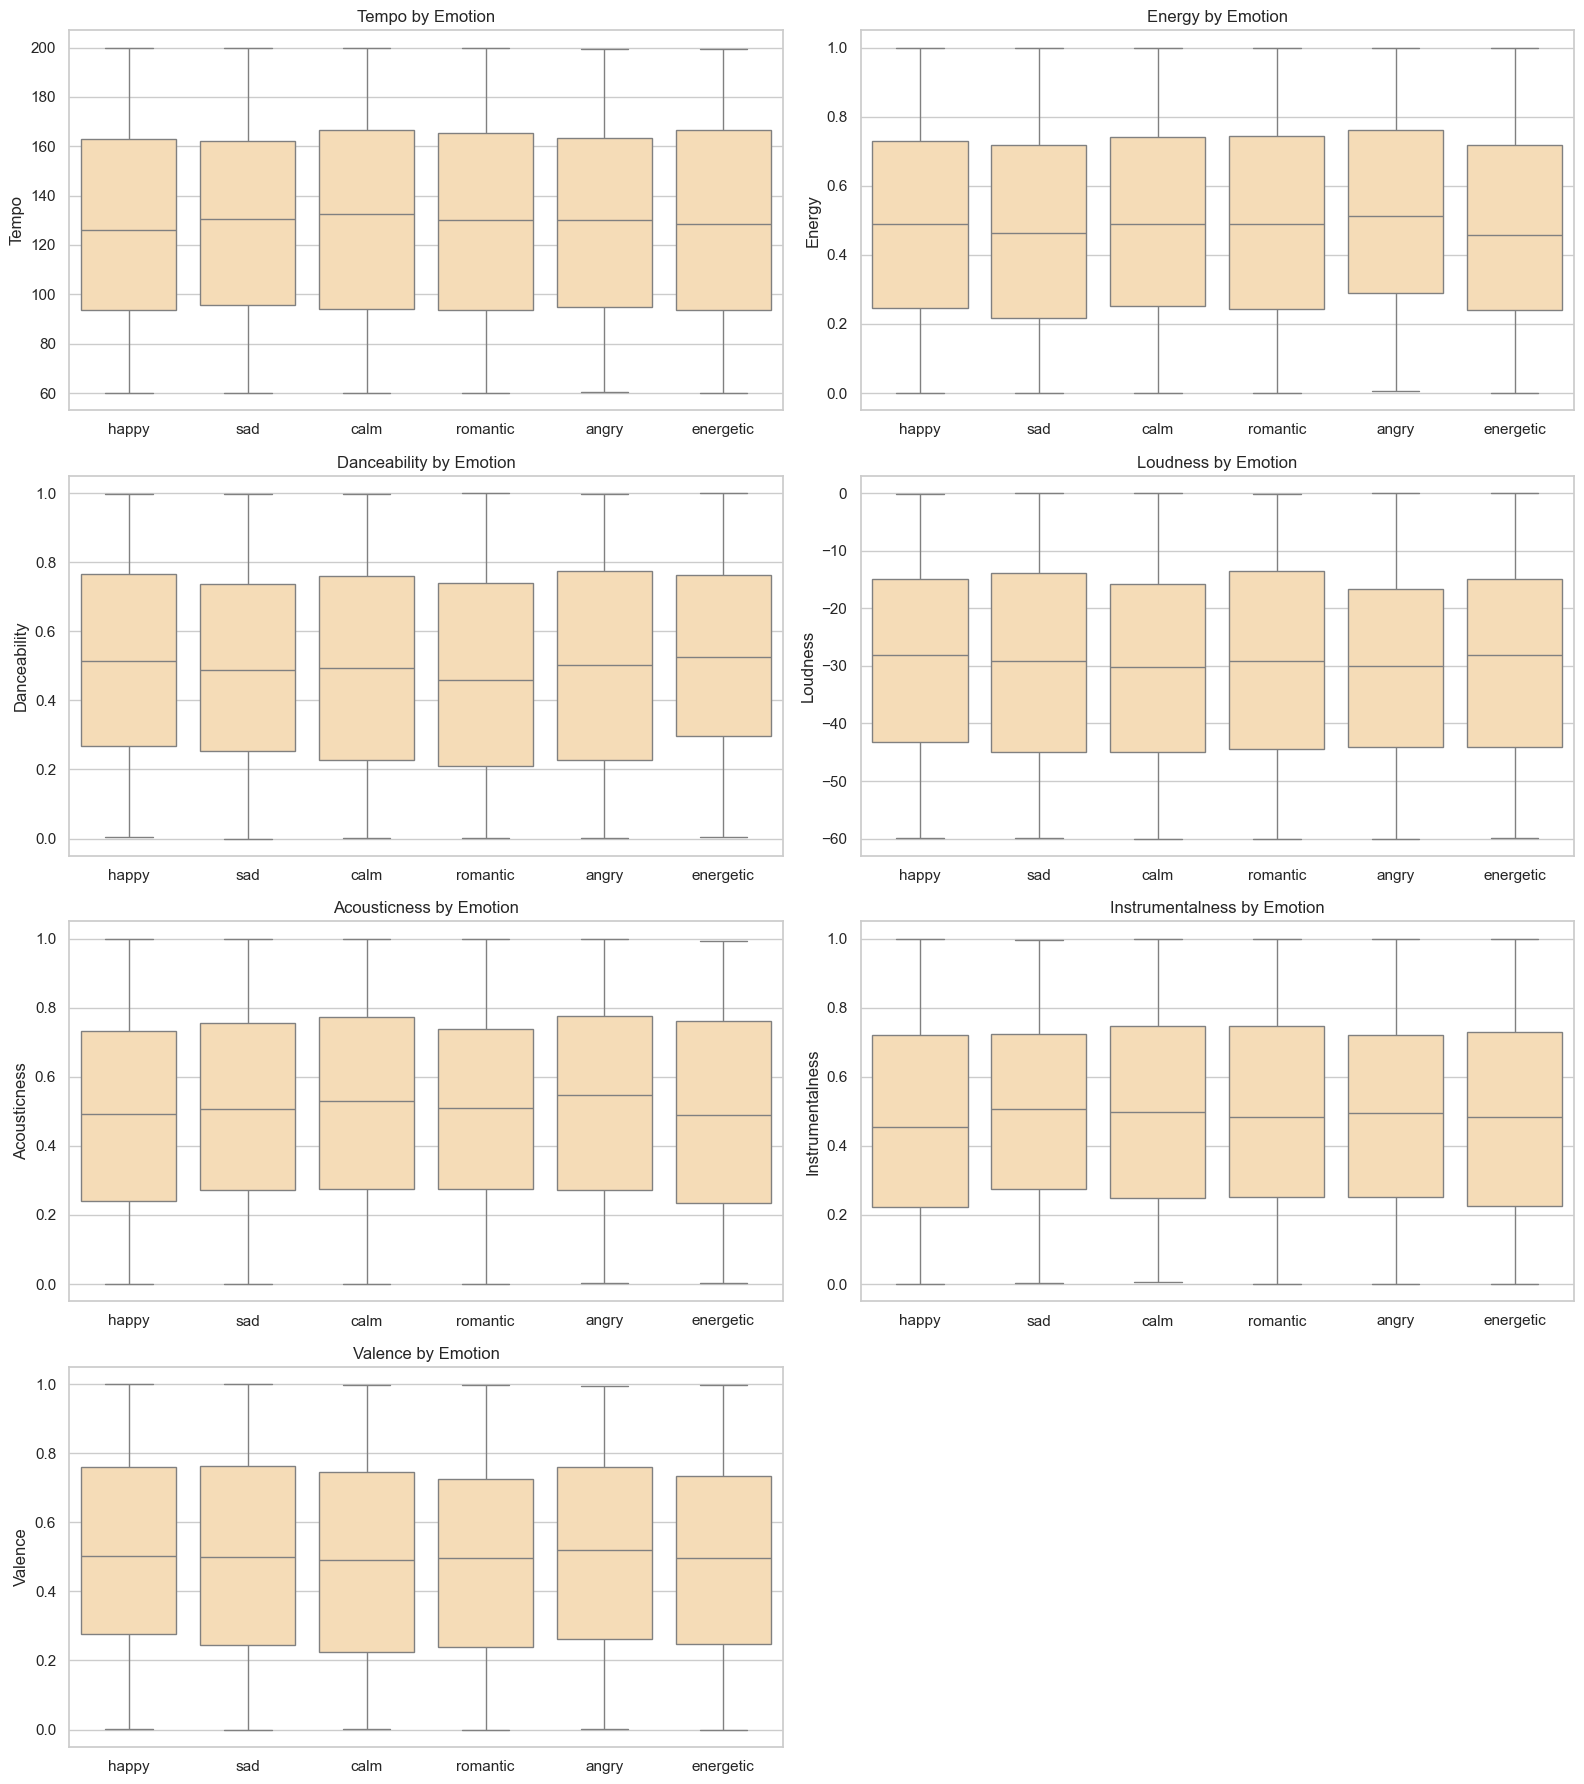

In [8]:
# Box plot of each feature split by emotion
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x="Emotion_Label", y=col, ax=ax, color="navajowhite")
    ax.set_title(f"{col} by Emotion")
    ax.set_xlabel("")

# Hide the unused 8th subplot
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

- Compares the range of each feature across the 6 emotions.
- As with genre, the distributions look very similar for every emotion (e.g. "sad" and "happy" have similar valence).

### 2.6 Feature Correlations

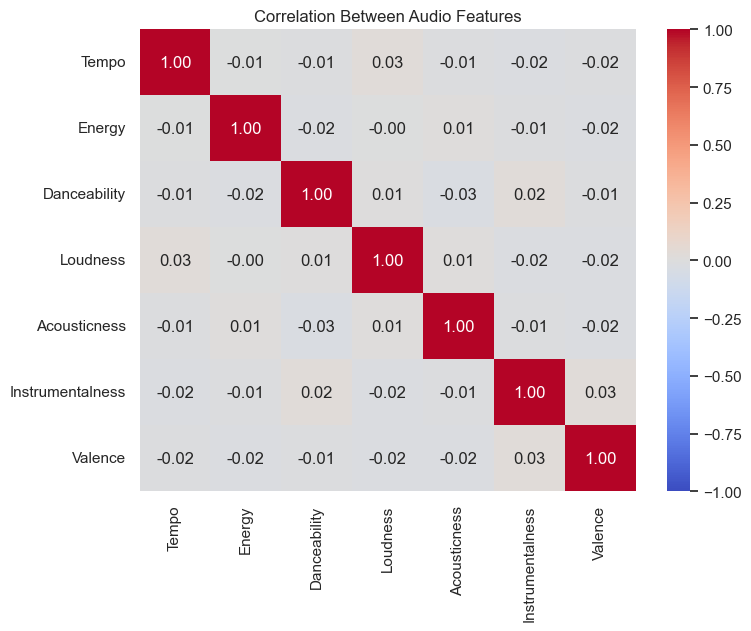

In [9]:
# Pearson correlation between every pair of numeric features
corr = df[FEATURES].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Audio Features")
plt.show()

- Shows how strongly each pair of features moves together (-1 to 1).
- All correlations are close to 0, so the features are independent of each other and none are redundant.

### 2.7 Genre vs. Emotion

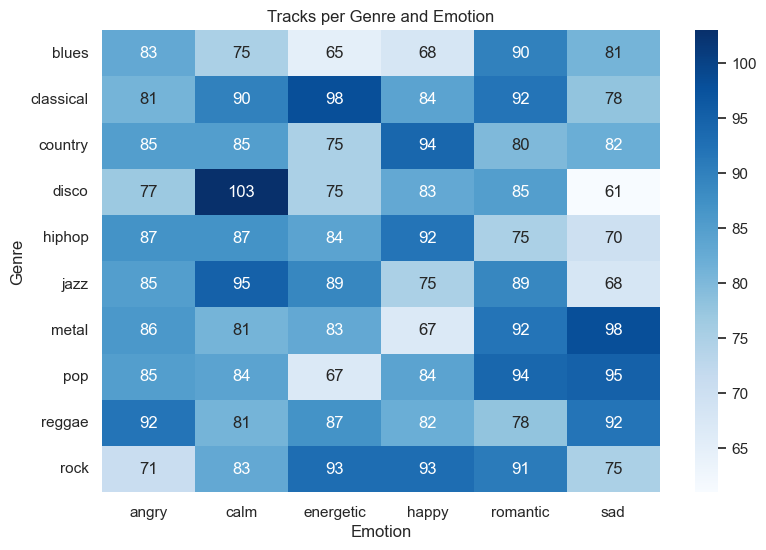

In [10]:
# Count of tracks for every genre / emotion combination
crosstab = pd.crosstab(df["Genre"], df["Emotion_Label"])

plt.figure(figsize=(9, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("Tracks per Genre and Emotion")
plt.xlabel("Emotion")
plt.ylabel("Genre")
plt.show()

- Shows how emotions are spread within each genre.
- Every genre contains every emotion in similar amounts (about 60–100 each), so genre does not strongly predict emotion.

## 3. Dataset Filtering and Cleaning

### 3.1 Missing Values

In [11]:
# Number of missing values in each column
df.isnull().sum()

Track_ID            0
Genre               0
Tempo               0
Energy              0
Danceability        0
Loudness            0
Acousticness        0
Instrumentalness    0
Valence             0
Emotion_Label       0
dtype: int64

- No missing values in any column.

### 3.2 Duplicates

In [12]:
# Fully duplicated rows and repeated track IDs
print("Duplicate rows:     ", df.duplicated().sum())
print("Duplicate Track_IDs:", df["Track_ID"].duplicated().sum())

Duplicate rows:      0
Duplicate Track_IDs: 0


- No duplicate rows or repeated track IDs.

### 3.3 Value Range Checks

In [13]:
# Expected valid range for each feature
valid_ranges = {
    "Tempo": (40, 250),
    "Energy": (0, 1),
    "Danceability": (0, 1),
    "Loudness": (-60, 0),
    "Acousticness": (0, 1),
    "Instrumentalness": (0, 1),
    "Valence": (0, 1),
}

# Count values that fall outside their valid range
for col, (low, high) in valid_ranges.items():
    out_of_range = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:17s} min={df[col].min():8.3f}  max={df[col].max():8.3f}  out of range: {out_of_range}")

Tempo             min=  60.000  max= 199.960  out of range: 0
Energy            min=   0.000  max=   1.000  out of range: 0
Danceability      min=   0.000  max=   1.000  out of range: 0
Loudness          min= -59.980  max=  -0.000  out of range: 0
Acousticness      min=   0.000  max=   1.000  out of range: 0
Instrumentalness  min=   0.000  max=   1.000  out of range: 0
Valence           min=   0.000  max=   1.000  out of range: 0


- All features are within their expected ranges, so no outliers were removed.

### 3.4 Categorical Label Checks

In [14]:
# Look for typos, extra spaces or inconsistent capitalisation in the labels
for col in ["Genre", "Emotion_Label"]:
    values = df[col].unique()
    cleaned = df[col].str.strip().str.lower().unique()
    print(f"{col}: {sorted(values)}")
    print(f"  Inconsistent labels found: {len(values) != len(cleaned)}\n")

Genre: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
  Inconsistent labels found: False

Emotion_Label: ['angry', 'calm', 'energetic', 'happy', 'romantic', 'sad']
  Inconsistent labels found: False



- Genre has exactly the 10 expected genres and Emotion_Label has 6 emotions.
- No typos, extra spaces or capitalisation issues.

### 3.5 Cleaning Summary

In [15]:
# Normalise -0.0 loudness values to 0.0 (same number, just a formatting quirk)
df["Loudness"] = df["Loudness"].replace(-0.0, 0.0)

print("Final shape:", df.shape)

Final shape: (5000, 10)


- No rows were removed: there were no missing values, duplicates, out-of-range values or bad labels.
- The only change: a `-0.0` loudness value was set to `0.0` (same value, just tidier).
- The dataset keeps all 5,000 tracks and 10 columns.

## 4. Dataset Pre-processing

Preprocessing has already been started (as seen in Section 2) and the remaining steps are planned below.

**Already applied (Section 2)**:
- Checked for missing values, duplicate rows, duplicate Track_IDs, out-of-range feature values and inconsistent labels. Since none were found, no rows were removed.
- Replaced -0.0 loudness values with 0.0 (formatting fix only). The dataset still has 5,000 tracks and 10 columns.

### 4.1 Feature and Target Selection

- Track_ID is an identifier that is not relevant due to each ID being unique, and keeping it could allow a model to memorise rows. For this reason, this column will be dropped.
- The correlation heatmap shows values close to 0 for every pair of numerical features, so no features are dependent or redundant, so all features will be included for testing. 
- Genre is a categorical audio-related feature that can be used as an input feature. Genre and emotion are also weakly related (Section 1.7), so Genre is not expected to be an overly dominant predictor of emotion.
- Target: Emotion_Label is our categorical target variable, containing 6 discrete emotion classes. The current goal for our model is to predict the emotional label of a song based on its features.
- Text labels will be converted into integers (with a utility such as LabelEncoder), preserving mapping so predictions can be translated.
- No label cleaning is needed, since Section 2.4 confirms that the 10 genres and 6 emotions are consistent.

### 4.2 Splitting Data Into Sets

Our plan is to split the data into about 70% training, 15% validation and 15% testing using train_test_split with a fixed random state for reproducibility. We also plan to use stratified sampling on the target so each split keeps the same class proportions, and this split is done before any scaling so that information from the validation and test sets cannot leak into training.

### 4.3 Feature Scaling

- Tempo (60–200) and Loudness (-60 to 0) are on a much larger scale than the other features (0–1), as noted in Section 1.3.
- Apply standardisation to all 7 features. Since the distributions are roughly uniform with no outliers, min-max scaling would also work, and the two can be compared.
- The scaler should be fitted on the training set only, then used to transform the validation and test sets.
- Scaling matters most for distance-based and gradient-based models (k-NN, logistic regression, neural network, etc.). Tree-based models are unaffected but should receive the same scaled data for a fair comparison.

### 4.4 Steps Deliberately Not Applied

- There are no missing values, so imputation is not necessary.
- No resampling is required since our Target is roughly balanced (about 840 per emotion).
- Every value is inside its valid range (Section 2.3), so there are no clear outliers to remove.
- There are no meaningul compressions due to the features being almost entirely uncorrelated, so no dimensionality reduction is required.

### 4.5 Planned Checks and Next Steps

Our group plans to rerun the shape, class balance and scaling checks on each of the final training, validation and test sets. Our expectation is for training mean to be about 0 and standard deviation to be about 1 for each scaled feature. The box plots (Sections 1.4 and 1.5) show very similar feature distributions across classes, so a simple baseline model will be trained first to determine how well the raw features can predict the target. If this baseline is weak, feature engineering (such as adding interaction terms like Energy x Valence) can be tested using only the training data, with processed splits being saved to ../data/ so later notebooks use identical data.

### 4.6 Github Repository Link

https://github.com/justinseeuoit/machine-learning-course-project